# Task 3: A/B Hypothesis Testing
**AlphaCare Insurance Solutions — Risk Analytics**

Testing four null hypotheses to identify statistically significant risk drivers.

| # | Null Hypothesis | KPI | Test |
|---|---|---|---|
| H1 | No risk differences across provinces | Claim Severity + Frequency | t-test + chi-squared |
| H2 | No risk differences between zip codes | Claim Severity + Frequency | t-test + chi-squared |
| H3 | No margin difference between zip codes | Margin | t-test |
| H4 | No risk difference between Women and Men | Claim Severity + Frequency | t-test + chi-squared |

In [1]:
import os
os.makedirs('../reports/figures', exist_ok=True)
print("reports/figures folder ready")

reports/figures folder ready


In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('../data/insurance_data_clean.csv', low_memory=False)

# Confirm derived columns exist
if 'LossRatio' not in df.columns:
    df['LossRatio'] = df['TotalClaims'] / df['TotalPremium'].replace(0, np.nan)
if 'Margin' not in df.columns:
    df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# Check PostalCode
print("Columns available:", df.columns.tolist())
print(f"\nShape: {df.shape}")
print(f"\nPostalCode present: {'PostalCode' in df.columns}")
if 'PostalCode' in df.columns:
    print(f"PostalCode unique values: {df['PostalCode'].nunique()}")

Columns available: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims', 'LossRatio', 'Margin']

Shape: (999805, 48)

PostalCode present: True
PostalCode unique values: 888


In [3]:
# ── KPI Definitions ──────────────────────────────────────────────────────────
# Claim Frequency: 1 if policy had any claim, 0 otherwise
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

# Claim Severity: average claim amount ONLY for policies that had a claim
# (used per-group, not as a column)

print("KPI Summary:")
print(f"  Policies with claims:    {df['HasClaim'].sum():,}  ({100*df['HasClaim'].mean():.2f}%)")
print(f"  Policies without claims: {(df['HasClaim']==0).sum():,}")
print(f"  Mean claim (claimants):  R{df[df['HasClaim']==1]['TotalClaims'].mean():,.2f}")
print(f"  Mean margin:             R{df['Margin'].mean():,.4f}")

KPI Summary:
  Policies with claims:    2,788  (0.28%)
  Policies without claims: 997,017
  Mean claim (claimants):  R23,273.39
  Mean margin:             R-2.9449


In [4]:
from scipy.stats import ttest_ind, chi2_contingency

def test_claim_severity(df, group_col, group_a, group_b):
    """t-test on claim severity between two groups (claims > 0 only)."""
    claims = df[df['TotalClaims'] > 0]
    a = claims[claims[group_col] == group_a]['TotalClaims']
    b = claims[claims[group_col] == group_b]['TotalClaims']
    t_stat, p_val = ttest_ind(a, b, equal_var=False)  # Welch's t-test
    return {
        'test': "Welch's t-test",
        'group_a': group_a, 'n_a': len(a), 'mean_a': a.mean(),
        'group_b': group_b, 'n_b': len(b), 'mean_b': b.mean(),
        't_stat': round(t_stat, 4), 'p_value': round(p_val, 6),
        'reject_H0': p_val < 0.05
    }

def test_claim_frequency(df, group_col, group_a, group_b):
    """Chi-squared test on claim frequency (HasClaim) between two groups."""
    sub = df[df[group_col].isin([group_a, group_b])]
    contingency = pd.crosstab(sub[group_col], sub['HasClaim'])
    chi2, p_val, dof, _ = chi2_contingency(contingency)
    freq_a = df[df[group_col]==group_a]['HasClaim'].mean()
    freq_b = df[df[group_col]==group_b]['HasClaim'].mean()
    return {
        'test': 'Chi-squared',
        'group_a': group_a, 'claim_freq_a': round(freq_a, 4),
        'group_b': group_b, 'claim_freq_b': round(freq_b, 4),
        'chi2_stat': round(chi2, 4), 'p_value': round(p_val, 6),
        'reject_H0': p_val < 0.05
    }

def test_margin(df, group_col, group_a, group_b):
    """t-test on Margin between two groups."""
    a = df[df[group_col] == group_a]['Margin']
    b = df[df[group_col] == group_b]['Margin']
    t_stat, p_val = ttest_ind(a, b, equal_var=False)
    return {
        'test': "Welch's t-test",
        'group_a': group_a, 'mean_margin_a': round(a.mean(), 2),
        'group_b': group_b, 'mean_margin_b': round(b.mean(), 2),
        't_stat': round(t_stat, 4), 'p_value': round(p_val, 6),
        'reject_H0': p_val < 0.05
    }

def print_result(result, hypothesis):
    decision = "✅ REJECT H₀" if result['reject_H0'] else "❌ FAIL TO REJECT H₀"
    print(f"\n{'='*55}")
    print(f"  {hypothesis}")
    print(f"  Test:    {result['test']}")
    print(f"  p-value: {result['p_value']}")
    print(f"  Decision: {decision}")
    print(f"{'='*55}")

print("Functions loaded.")

Functions loaded.


In [5]:
# ── H1: Province Risk ─────────────────────────────────────────────────────────
# Control: Western Cape (stable, large sample)
# Test:    Gauteng (highest LR, largest province)

print("H1: No risk differences across provinces")
print("  Control = Western Cape | Test = Gauteng\n")

# Claim Severity
sev_result = test_claim_severity(df, 'Province', 'Western Cape', 'Gauteng')
print_result(sev_result, "H1a — Claim Severity (Western Cape vs Gauteng)")
print(f"  Mean severity — Western Cape: R{sev_result['mean_a']:,.2f} | Gauteng: R{sev_result['mean_b']:,.2f}")

# Claim Frequency
freq_result = test_claim_frequency(df, 'Province', 'Western Cape', 'Gauteng')
print_result(freq_result, "H1b — Claim Frequency (Western Cape vs Gauteng)")
print(f"  Claim freq — Western Cape: {freq_result['claim_freq_a']:.2%} | Gauteng: {freq_result['claim_freq_b']:.2%}")

H1: No risk differences across provinces
  Control = Western Cape | Test = Gauteng


  H1a — Claim Severity (Western Cape vs Gauteng)
  Test:    Welch's t-test
  p-value: 0.030599
  Decision: ✅ REJECT H₀
  Mean severity — Western Cape: R28,095.85 | Gauteng: R22,243.88

  H1b — Claim Frequency (Western Cape vs Gauteng)
  Test:    Chi-squared
  p-value: 0.0
  Decision: ✅ REJECT H₀
  Claim freq — Western Cape: 0.22% | Gauteng: 0.34%


### H1 Interpretation
**[Fill in after running — use template below]**

- If both p < 0.05: *"We reject H₀ for provinces on both severity and frequency. Gauteng exhibits a [X]% higher average claim severity (R__ vs R__) and a [X]% higher claim frequency than Western Cape (p < 0.001). This provides strong statistical evidence for a regional risk premium adjustment."*
- If only one p < 0.05: *"We partially reject H₀ — significant difference in [severity/frequency] but not [the other]."*
- If both p ≥ 0.05: *"We fail to reject H₀ — no statistically significant difference between provinces at α = 0.05."*

In [6]:
# ── H2 & H3: Zip Code Risk & Margin ──────────────────────────────────────────

# Detect correct column name
zip_col = None
for candidate in ['PostalCode', 'PostalCode', 'ZipCode', 'postalcode']:
    if candidate in df.columns:
        zip_col = candidate
        break

if zip_col is None:
    print("⚠️  No PostalCode/ZipCode column found. Available columns:")
    print([c for c in df.columns if 'post' in c.lower() or 'zip' in c.lower() or 'code' in c.lower()])
else:
    print(f"Using column: '{zip_col}'")
    print(f"Unique zip codes: {df[zip_col].nunique()}")

    # Pick top 2 zip codes by policy count with enough claims for valid test
    zip_stats = (
        df.groupby(zip_col)
        .agg(
            policy_count=('TotalClaims', 'count'),
            claim_count=('HasClaim', 'sum'),
            avg_margin=('Margin', 'mean')
        )
        .query("claim_count >= 50")  # need enough claims for valid test
        .sort_values('policy_count', ascending=False)
    )
    print("\nTop zip codes by policy count (min 50 claims):")
    print(zip_stats.head(10))

    # Select control and test zip
    top_zips = zip_stats.head(2).index.tolist()
    zip_a, zip_b = top_zips[0], top_zips[1]
    print(f"\nSelected: Control = {zip_a} | Test = {zip_b}")

    # H2: Claim severity
    h2_sev = test_claim_severity(df, zip_col, zip_a, zip_b)
    print_result(h2_sev, f"H2a — Claim Severity ({zip_a} vs {zip_b})")

    # H2: Claim frequency
    h2_freq = test_claim_frequency(df, zip_col, zip_a, zip_b)
    print_result(h2_freq, f"H2b — Claim Frequency ({zip_a} vs {zip_b})")

    # H3: Margin
    h3_margin = test_margin(df, zip_col, zip_a, zip_b)
    print_result(h3_margin, f"H3 — Margin ({zip_a} vs {zip_b})")
    print(f"  Mean margin — {zip_a}: R{h3_margin['mean_margin_a']} | {zip_b}: R{h3_margin['mean_margin_b']}")

Using column: 'PostalCode'
Unique zip codes: 888

Top zip codes by policy count (min 50 claims):
            policy_count  claim_count  avg_margin
PostalCode                                       
2000              133488          486   -8.108061
122                49171          210  -22.859806
7784               28582           50  -13.468513
299                25546           67   19.559415
8000               11794           51  -16.036381

Selected: Control = 2000 | Test = 122

  H2a — Claim Severity (2000 vs 122)
  Test:    Welch's t-test
  p-value: 0.700208
  Decision: ❌ FAIL TO REJECT H₀

  H2b — Claim Frequency (2000 vs 122)
  Test:    Chi-squared
  p-value: 0.058003
  Decision: ❌ FAIL TO REJECT H₀

  H3 — Margin (2000 vs 122)
  Test:    Welch's t-test
  p-value: 0.244345
  Decision: ❌ FAIL TO REJECT H₀
  Mean margin — 2000: R-8.11 | 122: R-22.86


In [7]:
# ── H4: Gender Risk ───────────────────────────────────────────────────────────
print("H4: No risk difference between Women and Men")
print("  Control = Male | Test = Female\n")

# Filter to only Male / Female (exclude 'Not specified')
df_gender = df[df['Gender'].isin(['Male', 'Female'])]
print(f"  Male policies:   {(df_gender['Gender']=='Male').sum():,}")
print(f"  Female policies: {(df_gender['Gender']=='Female').sum():,}")

# Claim Severity
h4_sev = test_claim_severity(df_gender, 'Gender', 'Male', 'Female')
print_result(h4_sev, "H4a — Claim Severity (Male vs Female)")
print(f"  Mean severity — Male: R{h4_sev['mean_a']:,.2f} | Female: R{h4_sev['mean_b']:,.2f}")

# Claim Frequency
h4_freq = test_claim_frequency(df_gender, 'Gender', 'Male', 'Female')
print_result(h4_freq, "H4b — Claim Frequency (Male vs Female)")
print(f"  Claim freq — Male: {h4_freq['claim_freq_a']:.2%} | Female: {h4_freq['claim_freq_b']:.2%}")

H4: No risk difference between Women and Men
  Control = Male | Test = Female

  Male policies:   42,576
  Female policies: 6,755

  H4a — Claim Severity (Male vs Female)
  Test:    Welch's t-test
  p-value: 0.568029
  Decision: ❌ FAIL TO REJECT H₀
  Mean severity — Male: R14,858.55 | Female: R17,874.72

  H4b — Claim Frequency (Male vs Female)
  Test:    Chi-squared
  p-value: 0.93553
  Decision: ❌ FAIL TO REJECT H₀
  Claim freq — Male: 0.22% | Female: 0.21%


In [8]:
# ── Summary Results Table ─────────────────────────────────────────────────────

results = []

# H1
results.append({
    'Hypothesis': 'H1a — Province Severity',
    'Groups': 'Western Cape vs Gauteng',
    'Test': sev_result['test'],
    'p-value': sev_result['p_value'],
    'Decision': '✅ Reject H₀' if sev_result['reject_H0'] else '❌ Fail to Reject'
})
results.append({
    'Hypothesis': 'H1b — Province Frequency',
    'Groups': 'Western Cape vs Gauteng',
    'Test': freq_result['test'],
    'p-value': freq_result['p_value'],
    'Decision': '✅ Reject H₀' if freq_result['reject_H0'] else '❌ Fail to Reject'
})

# H2 & H3 (only if zip_col found)
if zip_col:
    results.append({
        'Hypothesis': 'H2a — Zip Severity',
        'Groups': f'{zip_a} vs {zip_b}',
        'Test': h2_sev['test'],
        'p-value': h2_sev['p_value'],
        'Decision': '✅ Reject H₀' if h2_sev['reject_H0'] else '❌ Fail to Reject'
    })
    results.append({
        'Hypothesis': 'H2b — Zip Frequency',
        'Groups': f'{zip_a} vs {zip_b}',
        'Test': h2_freq['test'],
        'p-value': h2_freq['p_value'],
        'Decision': '✅ Reject H₀' if h2_freq['reject_H0'] else '❌ Fail to Reject'
    })
    results.append({
        'Hypothesis': 'H3 — Zip Margin',
        'Groups': f'{zip_a} vs {zip_b}',
        'Test': h3_margin['test'],
        'p-value': h3_margin['p_value'],
        'Decision': '✅ Reject H₀' if h3_margin['reject_H0'] else '❌ Fail to Reject'
    })

# H4
results.append({
    'Hypothesis': 'H4a — Gender Severity',
    'Groups': 'Male vs Female',
    'Test': h4_sev['test'],
    'p-value': h4_sev['p_value'],
    'Decision': '✅ Reject H₀' if h4_sev['reject_H0'] else '❌ Fail to Reject'
})
results.append({
    'Hypothesis': 'H4b — Gender Frequency',
    'Groups': 'Male vs Female',
    'Test': h4_freq['test'],
    'p-value': h4_freq['p_value'],
    'Decision': '✅ Reject H₀' if h4_freq['reject_H0'] else '❌ Fail to Reject'
})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Hypothesis                  Groups           Test  p-value         Decision
 H1a — Province Severity Western Cape vs Gauteng Welch's t-test 0.030599      ✅ Reject H₀
H1b — Province Frequency Western Cape vs Gauteng    Chi-squared 0.000000      ✅ Reject H₀
      H2a — Zip Severity             2000 vs 122 Welch's t-test 0.700208 ❌ Fail to Reject
     H2b — Zip Frequency             2000 vs 122    Chi-squared 0.058003 ❌ Fail to Reject
         H3 — Zip Margin             2000 vs 122 Welch's t-test 0.244345 ❌ Fail to Reject
   H4a — Gender Severity          Male vs Female Welch's t-test 0.568029 ❌ Fail to Reject
  H4b — Gender Frequency          Male vs Female    Chi-squared 0.935530 ❌ Fail to Reject


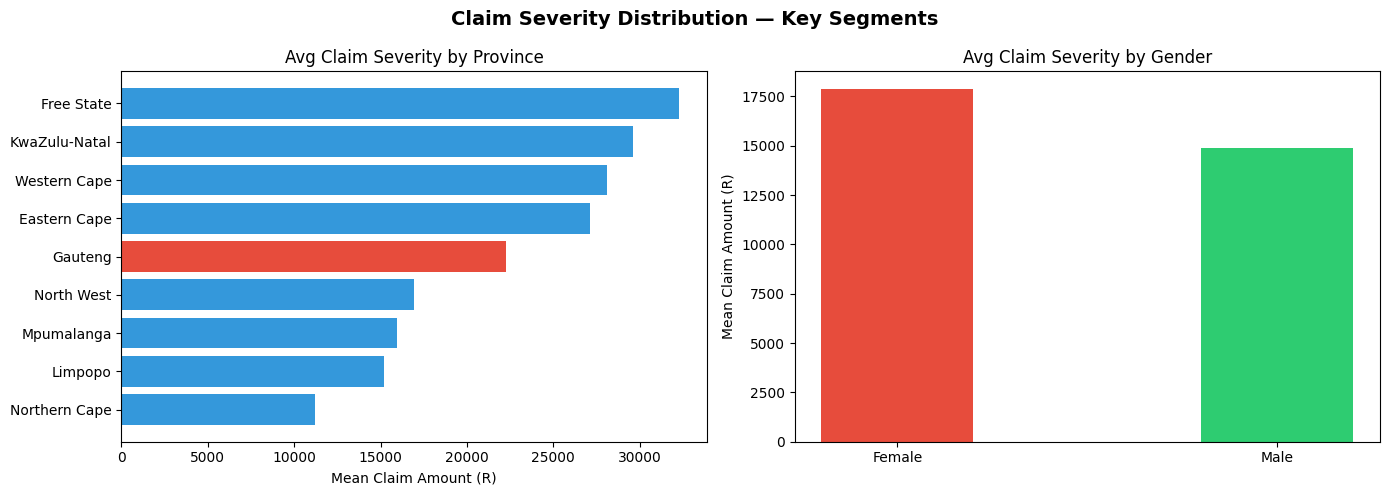

In [9]:
# ── Visualization: Claim Severity by Province & Gender ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Claim Severity Distribution — Key Segments", fontsize=14, fontweight='bold')

claims_only = df[df['TotalClaims'] > 0]

# Province
prov_sev = claims_only.groupby('Province')['TotalClaims'].mean().sort_values(ascending=False)
axes[0].barh(prov_sev.index, prov_sev.values, color=['#e74c3c' if p == 'Gauteng' else '#3498db' for p in prov_sev.index])
axes[0].set_xlabel('Mean Claim Amount (R)')
axes[0].set_title('Avg Claim Severity by Province')
axes[0].invert_yaxis()

# Gender
gen_sev = claims_only[claims_only['Gender'].isin(['Male','Female'])].groupby('Gender')['TotalClaims'].mean()
colors = ['#e74c3c' if g == 'Female' else '#2ecc71' for g in gen_sev.index]
axes[1].bar(gen_sev.index, gen_sev.values, color=colors, width=0.4)
axes[1].set_ylabel('Mean Claim Amount (R)')
axes[1].set_title('Avg Claim Severity by Gender')

plt.tight_layout()
plt.savefig('../reports/figures/hypothesis_results.png', dpi=150, bbox_inches='tight')
plt.show()